In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [2]:
df = pd.read_csv('clean_gym_data.csv')
df.head()

,country,year,region,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
0,Angola,2000,Africa,95521.0,0.3873,5731259.0,204.0,0.0059,0.5051,0.0470,563.7338,16194869.0,5.0,0.2219
1,Angola,2001,Africa,103840.0,0.3939,6230372.0,222.0,0.0062,0.5172,0.0496,533.5862,16747208.0,5.0,0.2192
2,Angola,2002,Africa,121093.0,0.4003,7265583.0,249.0,0.0070,0.5289,0.0522,999.0659,17327699.0,5.0,0.2164
3,Angola,2003,Africa,142783.0,0.4065,8566966.0,281.0,0.0080,0.5400,0.0548,1133.6633,17943712.0,5.0,0.2137
4,Angola,2004,Africa,179615.0,0.4124,10776918.0,325.0,0.0097,0.5504,0.0574,1451.4712,18600423.0,5.0,0.2110


## Basic Overview

In [3]:
df.shape

(3564, 14)

In [4]:
df.dtypes

country                                   str
year                                    int64
region                                    str
gym_memberships                       float64
fitness_participation_rate            float64
total_health_club_revenue_usd         float64
number_of_gyms                        float64
gym_penetration_rate                  float64
urban_population_percentage           float64
obesity_rate                          float64
gdp_per_capita_usd                    float64
population_total                      float64
average_membership_cost_usd           float64
insufficient_physical_activity_pct    float64
dtype: object

In [5]:
df.describe()

,year,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
count,3564.000000,3.564000e+03,3564.000000,3.564000e+03,3564.000000,3564.000000,3564.000000,3564.000000,3564.000000,3.564000e+03,3564.000000,3564.000000
mean,2013.000000,2.376142e+06,0.397892,6.034040e+08,2076.547138,0.067213,0.610007,0.187892,15615.268427,5.185536e+07,14.371563,0.272071
std,7.789974,7.129730e+06,0.087345,2.981056e+09,5227.710072,0.057984,0.219071,0.104702,21272.389671,1.657860e+08,14.064816,0.118444
min,2000.000000,2.051000e+03,0.204700,1.648750e+05,3.000000,0.002300,0.116400,0.002800,109.593800,1.816850e+05,5.000000,0.027000
25%,2006.000000,1.628528e+05,0.333100,1.533129e+07,205.000000,0.019600,0.463475,0.102975,2011.057500,4.467102e+06,5.060000,0.188000
50%,2013.000000,5.108880e+05,0.399900,5.568824e+07,556.000000,0.052200,0.633950,0.196100,5830.212650,1.210349e+07,8.055000,0.250100
75%,2020.000000,1.560638e+06,0.453750,2.737641e+08,1580.750000,0.099500,0.784175,0.259400,21455.622900,3.803110e+07,17.792500,0.345025
max,2026.000000,1.027881e+08,0.675800,8.486183e+10,62233.000000,0.302200,1.000000,0.612400,137781.681700,1.450936e+09,90.920000,0.661400


In [6]:
df.isnull().sum()

country                               0
year                                  0
region                                0
gym_memberships                       0
fitness_participation_rate            0
total_health_club_revenue_usd         0
number_of_gyms                        0
gym_penetration_rate                  0
urban_population_percentage           0
obesity_rate                          0
gdp_per_capita_usd                    0
population_total                      0
average_membership_cost_usd           0
insufficient_physical_activity_pct    0
dtype: int64

---
## Target Variable: `gym_penetration_rate`

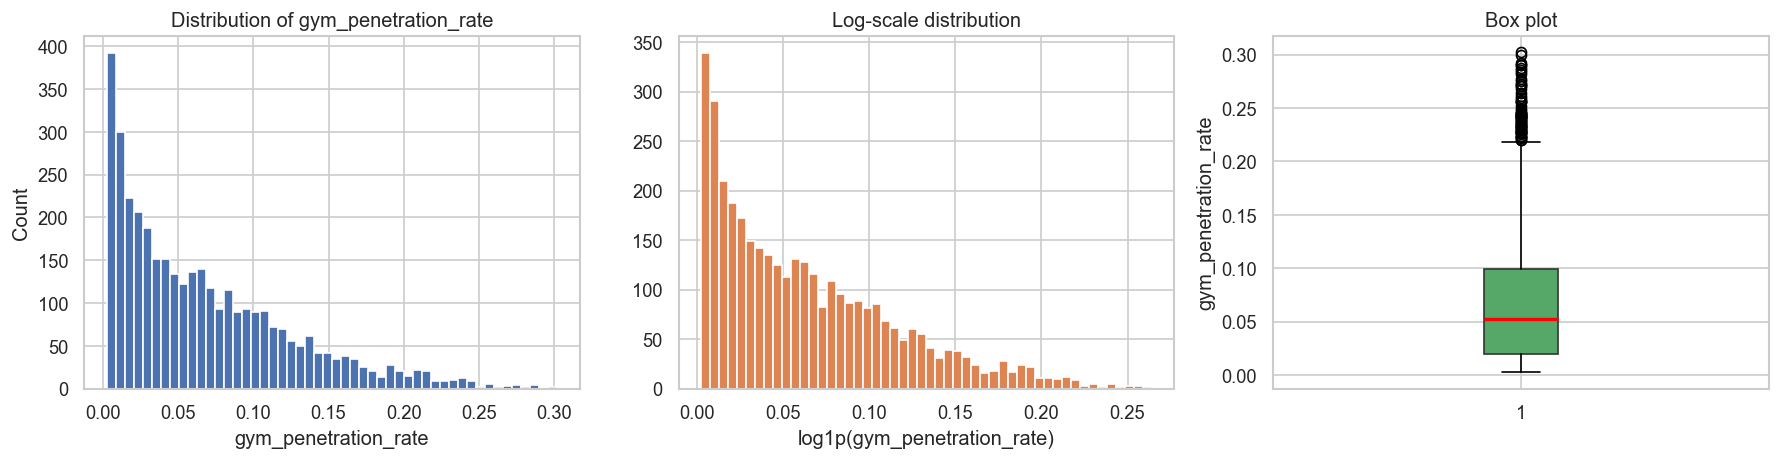

count    3564.0000
mean        0.0672
std         0.0580
min         0.0023
25%         0.0196
50%         0.0522
75%         0.0995
max         0.3022
Name: gym_penetration_rate, dtype: float64

Skewness : 1.137
Kurtosis : 0.902


In [7]:
target = "gym_penetration_rate"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution
axes[0].hist(df[target], bins=50, edgecolor="white", color="#4c72b0")
axes[0].set_title("Distribution of gym_penetration_rate")
axes[0].set_xlabel("gym_penetration_rate")
axes[0].set_ylabel("Count")

# Log-scale distribution
axes[1].hist(np.log1p(df[target]), bins=50, edgecolor="white", color="#dd8452")
axes[1].set_title("Log-scale distribution")
axes[1].set_xlabel("log1p(gym_penetration_rate)")

# Box plot
axes[2].boxplot(df[target], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#55a868", color="#333"),
                medianprops=dict(color="red", linewidth=2))
axes[2].set_title("Box plot")
axes[2].set_ylabel("gym_penetration_rate")

plt.tight_layout()
plt.show()

print(df[target].describe().round(4))
print(f"\nSkewness : {df[target].skew():.3f}")
print(f"Kurtosis : {df[target].kurt():.3f}")


---
## Feature Distributions

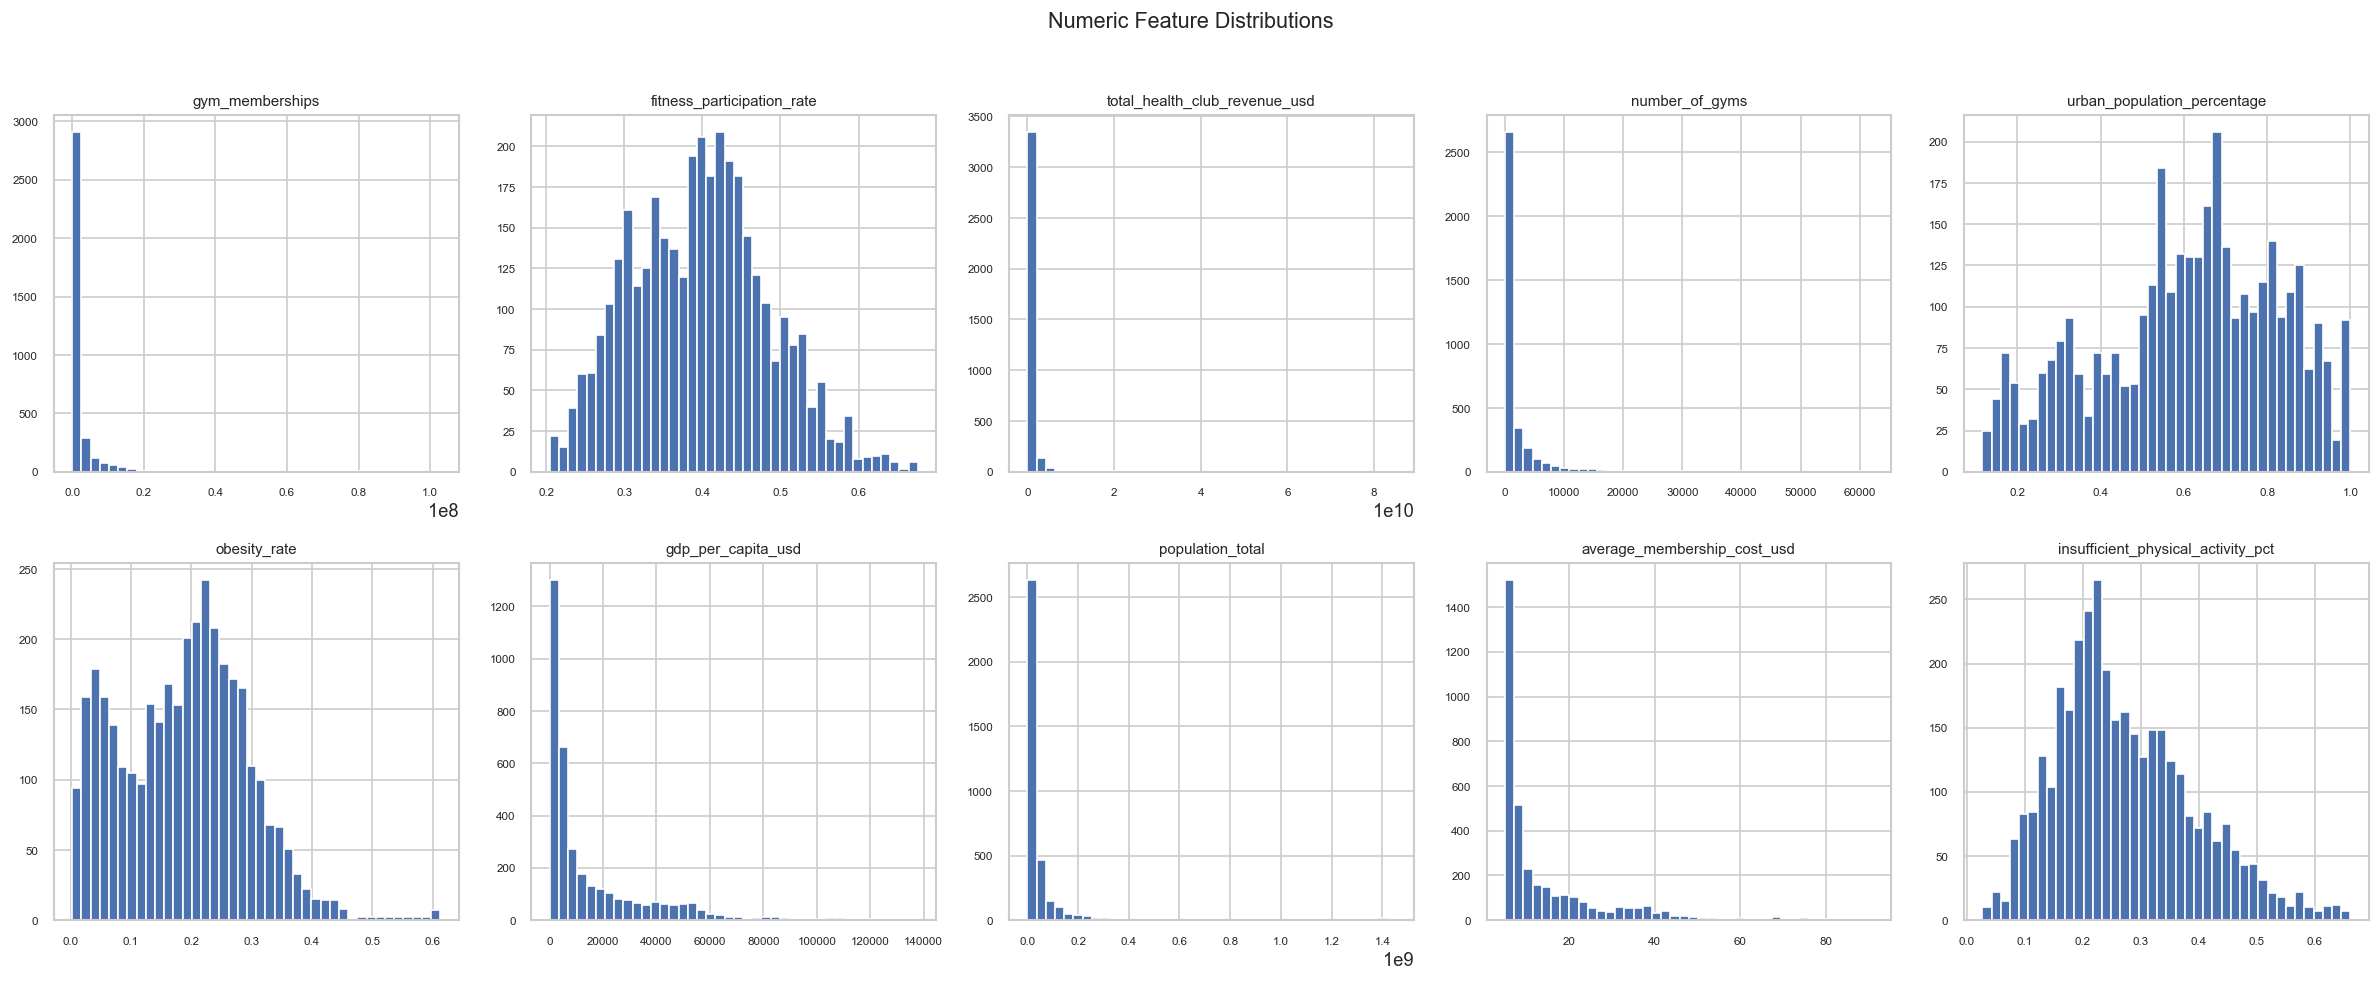

In [8]:
numeric_features = [
    "gym_memberships", "fitness_participation_rate",
    "total_health_club_revenue_usd", "number_of_gyms",
    "urban_population_percentage", "obesity_rate",
    "gdp_per_capita_usd", "population_total",
    "average_membership_cost_usd", "insufficient_physical_activity_pct",
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col], bins=40, edgecolor="white", color="#4c72b0")
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

plt.suptitle("Numeric Feature Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## Regional Analysis

/var/folders/h8/vtv9bx_x4lv6302qf1vy44180000gn/T/ipykernel_14438/1107625329.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="region", y=target, order=region_order, ax=axes[0], palette="Set2")


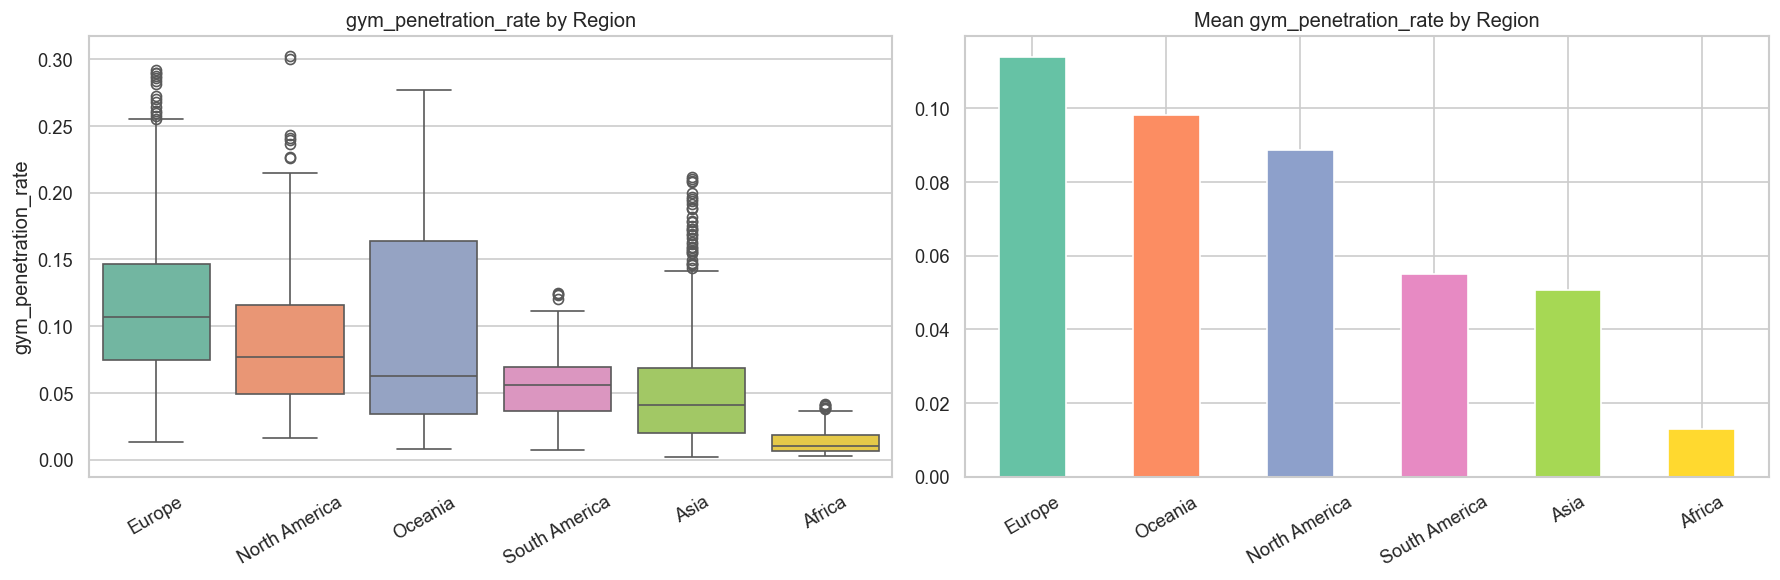

                count    mean     std     min     25%     50%     75%     max
region                                                                       
Africa          783.0  0.0130  0.0085  0.0026  0.0062  0.0102  0.0184  0.0413
Asia            918.0  0.0508  0.0408  0.0023  0.0196  0.0406  0.0690  0.2114
Europe         1080.0  0.1138  0.0548  0.0129  0.0743  0.1071  0.1467  0.2919
North America   324.0  0.0888  0.0522  0.0165  0.0488  0.0770  0.1155  0.3022
Oceania         135.0  0.0980  0.0800  0.0076  0.0339  0.0628  0.1639  0.2770
South America   324.0  0.0550  0.0244  0.0072  0.0365  0.0557  0.0691  0.1249


In [9]:
region_order = (
    df.groupby("region")[target].median()
    .sort_values(ascending=False).index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot by region
sns.boxplot(data=df, x="region", y=target, order=region_order, ax=axes[0], palette="Set2")
axes[0].set_title("gym_penetration_rate by Region")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

# Mean penetration rate by region (bar)
region_means = df.groupby("region")[target].mean().sort_values(ascending=False)
region_means.plot(kind="bar", ax=axes[1], color=sns.color_palette("Set2", len(region_means)), edgecolor="white")
axes[1].set_title("Mean gym_penetration_rate by Region")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print(df.groupby("region")[target].describe().round(4))


---
## Temporal Analysis

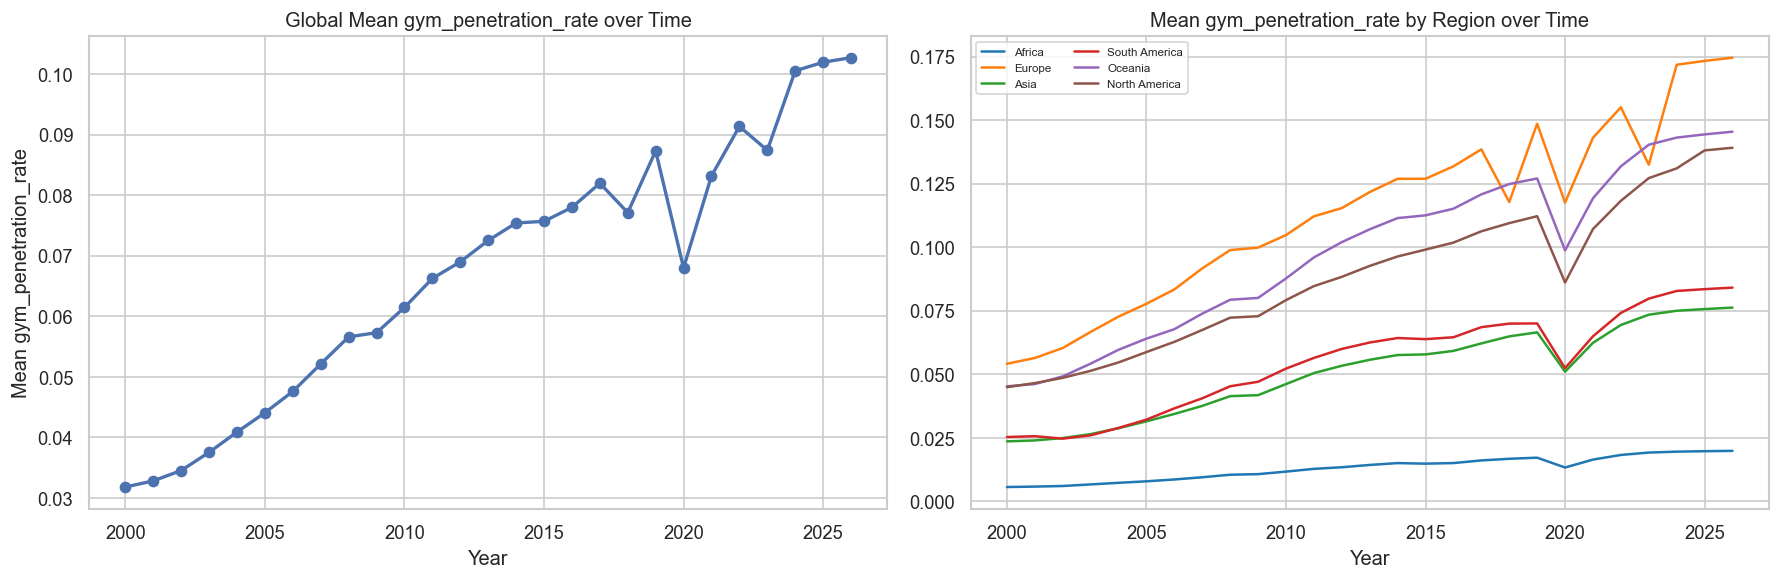

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Global mean penetration over time
yearly_global = df.groupby("year")[target].mean()
axes[0].plot(yearly_global.index, yearly_global.values, marker="o", linewidth=2, color="#4c72b0")
axes[0].set_title("Global Mean gym_penetration_rate over Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mean gym_penetration_rate")

# Mean by region over time
region_year = df.groupby(["year", "region"])[target].mean().reset_index()
palette = sns.color_palette("tab10", n_colors=df["region"].nunique())
for idx, reg in enumerate(df["region"].unique()):
    sub = region_year[region_year["region"] == reg]
    axes[1].plot(sub["year"], sub[target], label=reg, linewidth=1.5, color=palette[idx])

axes[1].set_title("Mean gym_penetration_rate by Region over Time")
axes[1].set_xlabel("Year")
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()


---
## Top & Bottom Countries by Average Penetration Rate

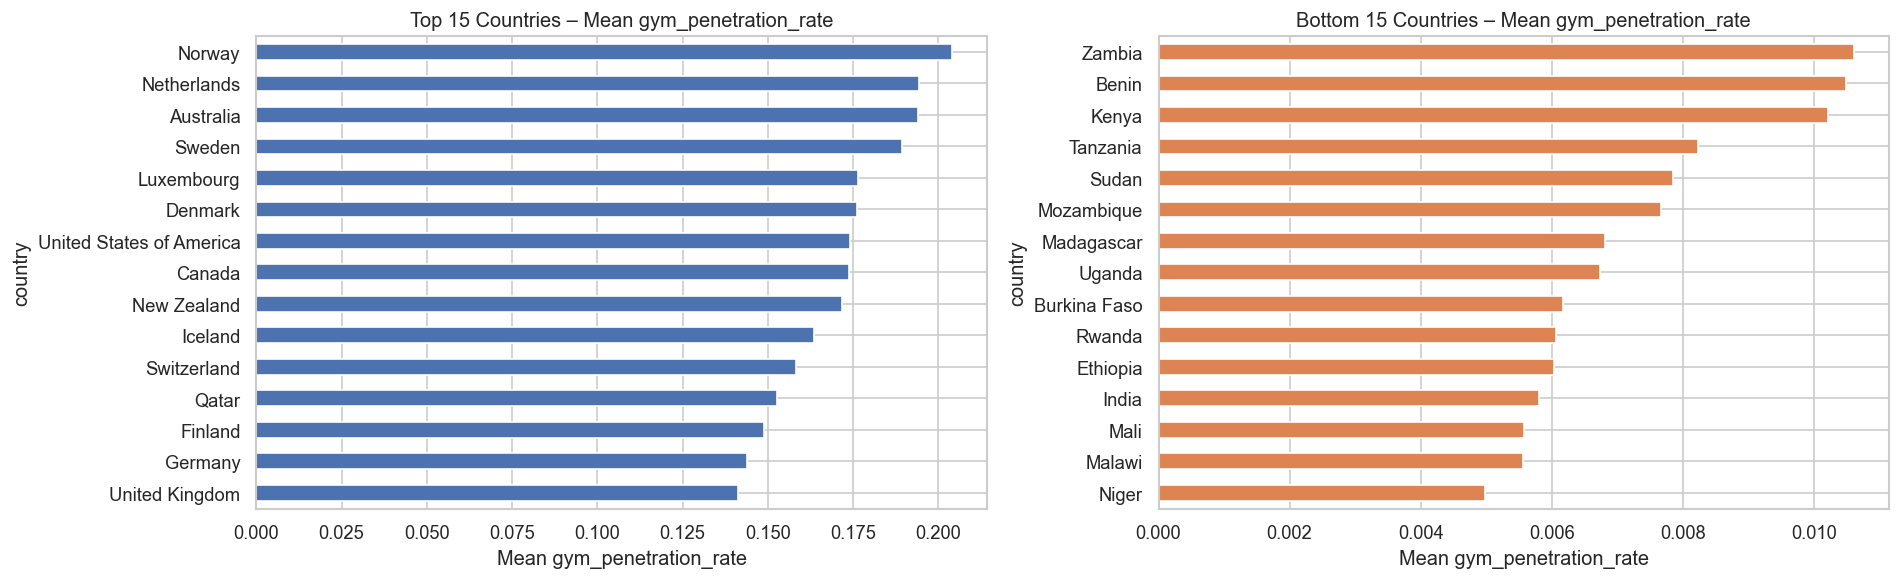

In [11]:
country_avg = df.groupby("country")[target].mean().sort_values(ascending=False)
n = 15

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

country_avg.head(n).plot(kind="barh", ax=axes[0], color="#4c72b0", edgecolor="white")
axes[0].invert_yaxis()
axes[0].set_title(f"Top {n} Countries – Mean gym_penetration_rate")
axes[0].set_xlabel("Mean gym_penetration_rate")

country_avg.tail(n).plot(kind="barh", ax=axes[1], color="#dd8452", edgecolor="white")
axes[1].invert_yaxis()
axes[1].set_title(f"Bottom {n} Countries – Mean gym_penetration_rate")
axes[1].set_xlabel("Mean gym_penetration_rate")

plt.tight_layout()
plt.show()


---
## Correlation Analysis

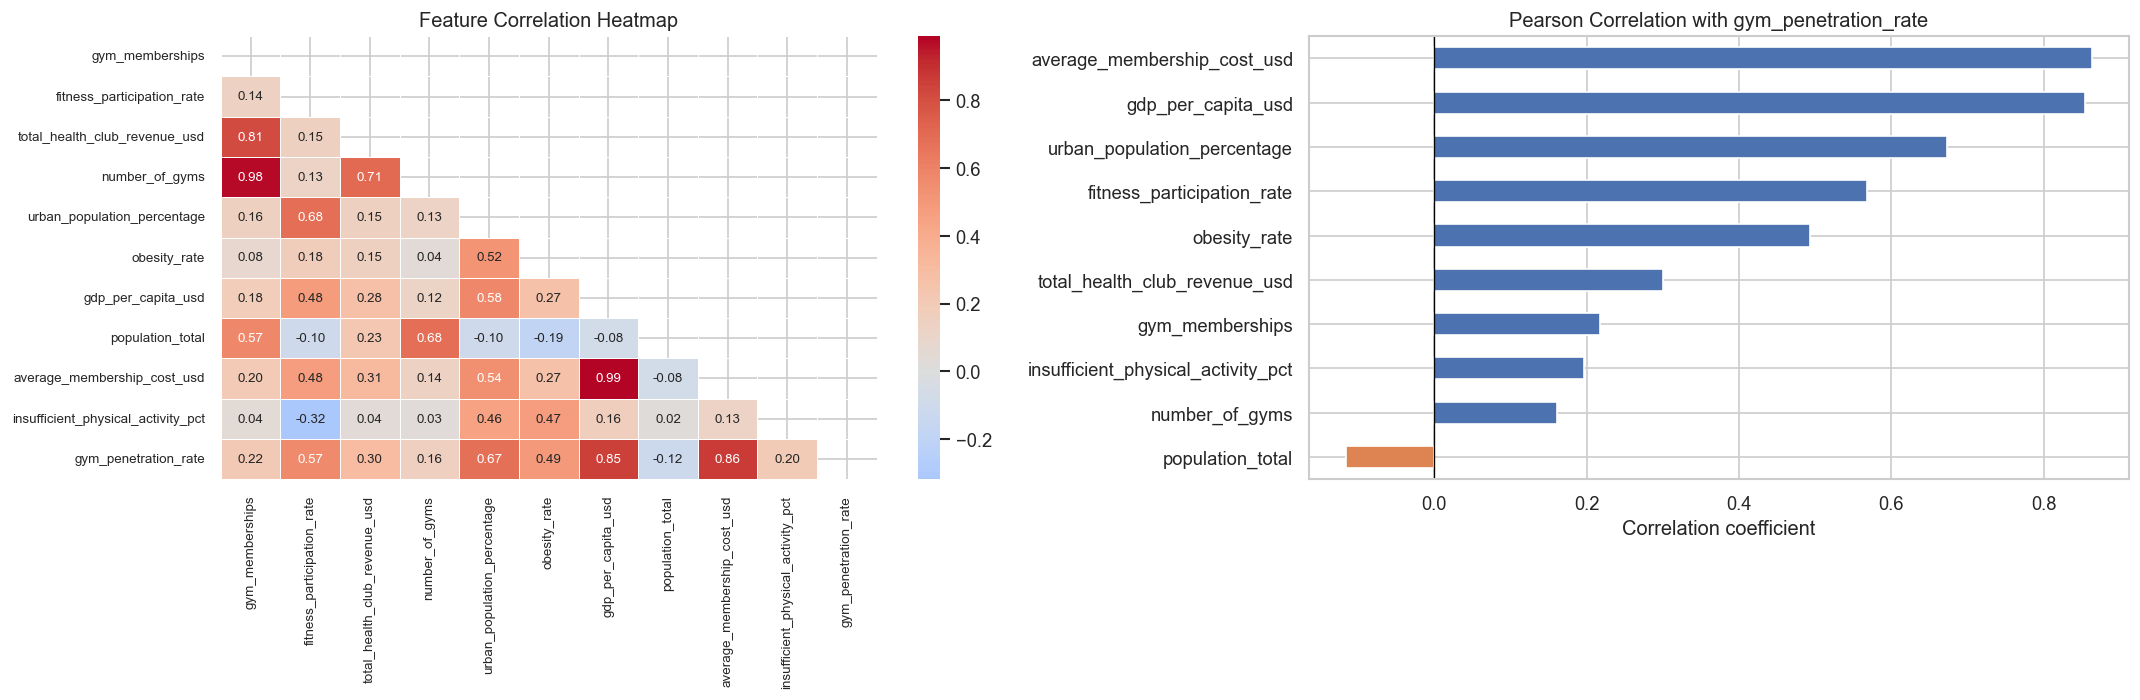


Correlation with gym_penetration_rate (sorted):
population_total                     -0.1154
number_of_gyms                        0.1613
insufficient_physical_activity_pct    0.1970
gym_memberships                       0.2172
total_health_club_revenue_usd         0.3002
obesity_rate                          0.4932
fitness_participation_rate            0.5682
urban_population_percentage           0.6729
gdp_per_capita_usd                    0.8546
average_membership_cost_usd           0.8626


In [12]:
numeric_cols = numeric_features + [target]
corr_matrix = df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Full correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=axes[0], annot_kws={"size": 8})
axes[0].set_title("Feature Correlation Heatmap")
axes[0].tick_params(labelsize=8)

# Correlation with target only
target_corr = corr_matrix[target].drop(target).sort_values()
colors = ["#dd8452" if v < 0 else "#4c72b0" for v in target_corr]
target_corr.plot(kind="barh", ax=axes[1], color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title(f"Pearson Correlation with {target}")
axes[1].set_xlabel("Correlation coefficient")

plt.tight_layout()
plt.show()

print("\nCorrelation with gym_penetration_rate (sorted):")
print(target_corr.round(4).to_string())


---
## Multicollinearity Check

In [14]:
high_corr_pairs = []
for i in range(len(numeric_features)):
    for j in range(i + 1, len(numeric_features)):
        c1, c2 = numeric_features[i], numeric_features[j]
        r = df[[c1, c2]].corr().iloc[0, 1]
        if abs(r) >= 0.80:
            high_corr_pairs.append((c1, c2, round(r, 3)))

print("Feature pairs with |r| >= 0.80 (risk of multicollinearity):")
if high_corr_pairs:
    for c1, c2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
        print(f"  {c1}  <->  {c2}   r={r}")
else:
    print("  None found.")


Feature pairs with |r| >= 0.80 (risk of multicollinearity):
  gdp_per_capita_usd  <->  average_membership_cost_usd   r=0.989
  gym_memberships  <->  number_of_gyms   r=0.977
  gym_memberships  <->  total_health_club_revenue_usd   r=0.812


---
## Mutual Information (Non-linear Feature Relevance)

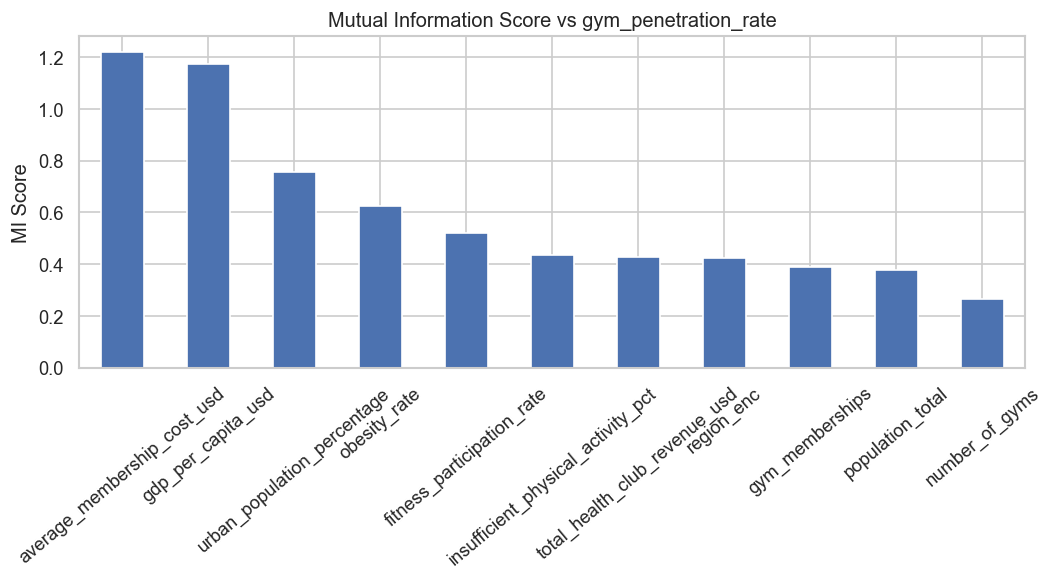


Mutual Information Scores (higher = more informative):
average_membership_cost_usd           1.2194
gdp_per_capita_usd                    1.1742
urban_population_percentage           0.7557
obesity_rate                          0.6244
fitness_participation_rate            0.5211
insufficient_physical_activity_pct    0.4355
total_health_club_revenue_usd         0.4268
region_enc                            0.4252
gym_memberships                       0.3874
population_total                      0.3763
number_of_gyms                        0.2649


In [15]:
le = LabelEncoder()
df_mi = df[numeric_features + ["region"]].copy()
df_mi["region_enc"] = le.fit_transform(df["region"])

mi_features = numeric_features + ["region_enc"]
X_mi = df_mi[mi_features].values
y_mi = df[target].values

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=mi_features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
mi_series.plot(kind="bar", ax=ax, color="#4c72b0", edgecolor="white")
ax.set_title("Mutual Information Score vs gym_penetration_rate")
ax.set_ylabel("MI Score")
ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.show()

print("\nMutual Information Scores (higher = more informative):")
print(mi_series.round(4).to_string())


---
## Outlier Detection (IQR Method)

                           feature  n_outliers   pct
                   gym_memberships         522 14.65
     total_health_club_revenue_usd         514 14.42
                    number_of_gyms         493 13.83
                  population_total         374 10.49
       average_membership_cost_usd         298  8.36
                gdp_per_capita_usd         287  8.05
              gym_penetration_rate          72  2.02
insufficient_physical_activity_pct          52  1.46
        fitness_participation_rate          21  0.59
                      obesity_rate          21  0.59
       urban_population_percentage           0  0.00


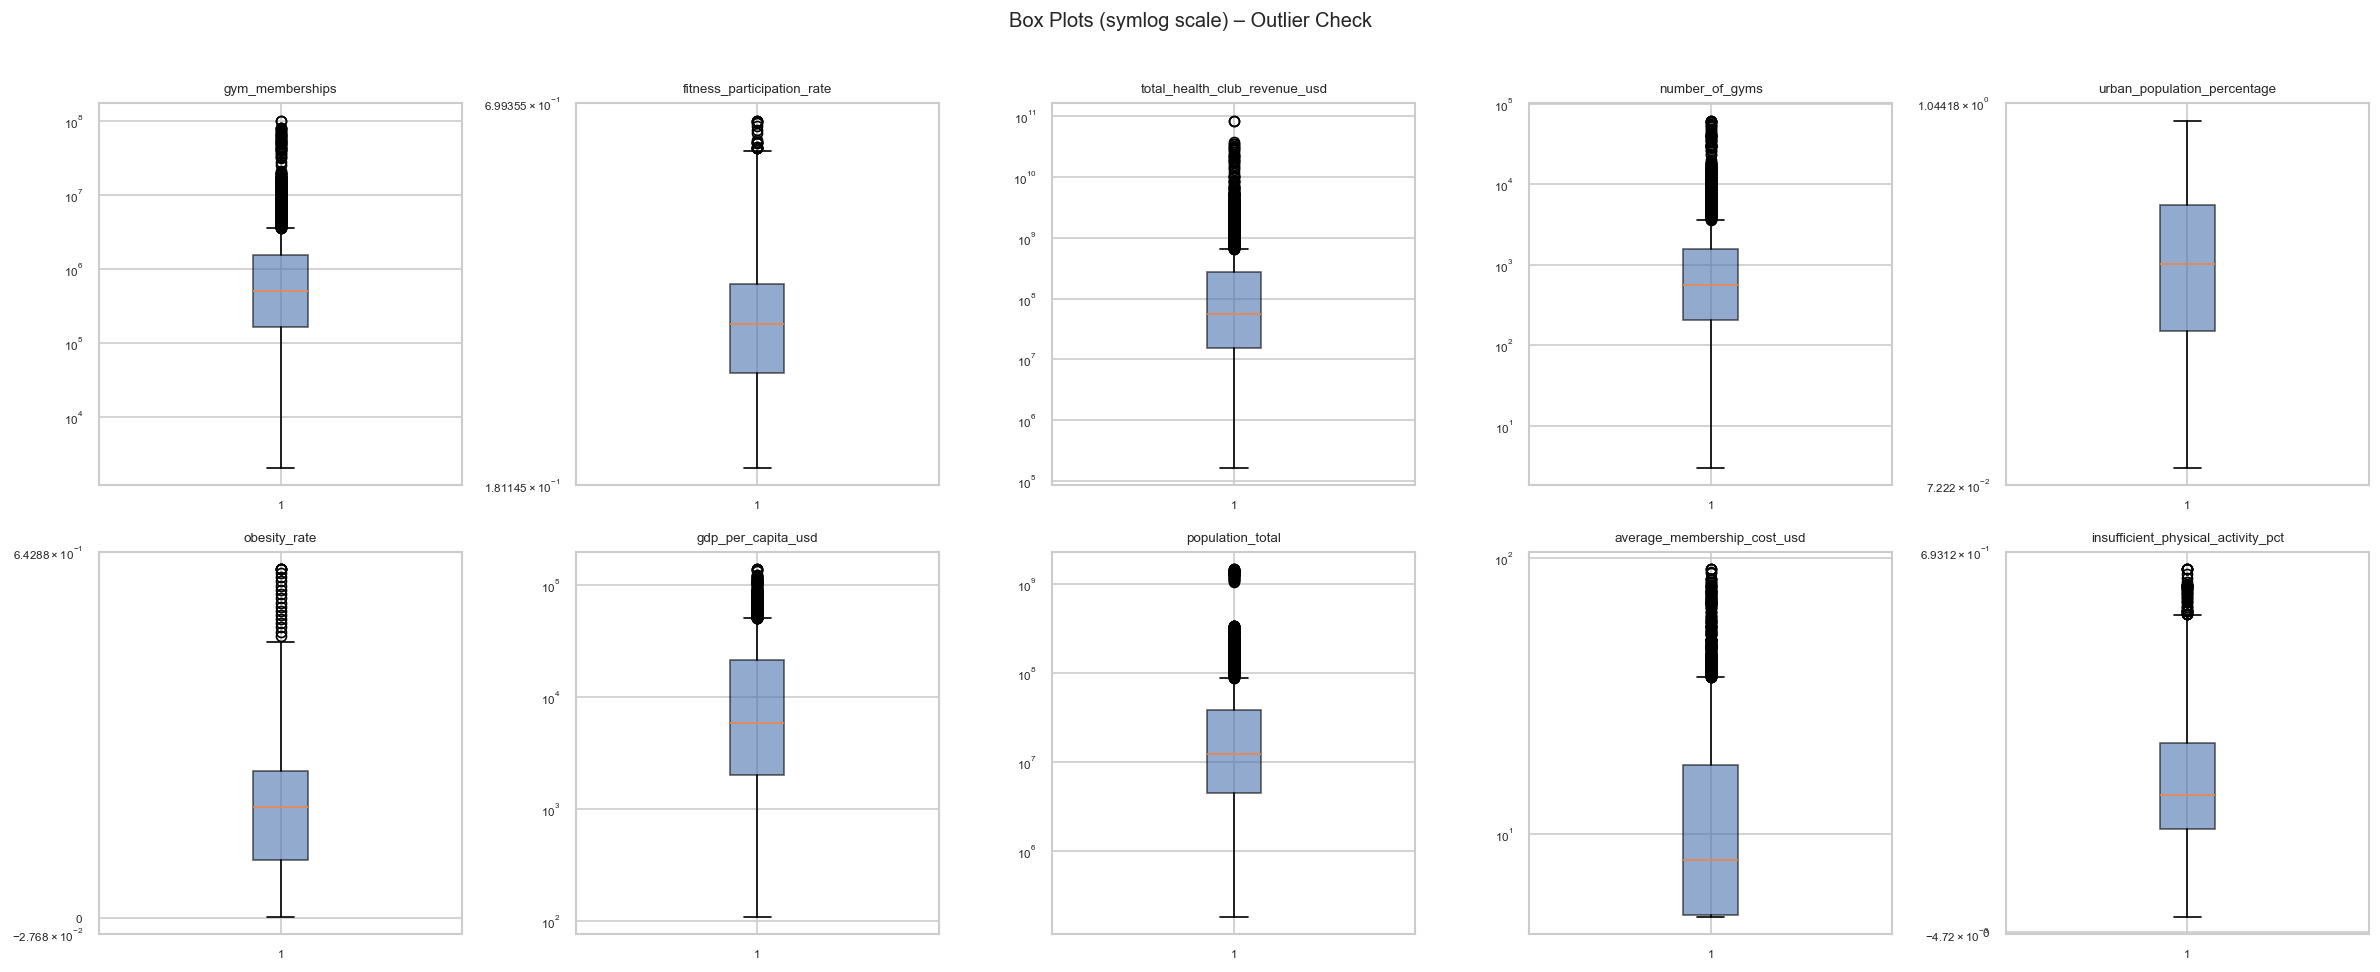

In [16]:
outlier_summary = []
for col in numeric_features + [target]:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({"feature": col, "n_outliers": n_out,
                             "pct": round(100 * n_out / len(df), 2)})

outlier_df = pd.DataFrame(outlier_summary).sort_values("pct", ascending=False)
print(outlier_df.to_string(index=False))

# Visualise as box plots side by side (log-scaled for scale differences)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#4c72b0", alpha=0.6))
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=7)
    axes[i].set_yscale("symlog")

plt.suptitle("Box Plots (symlog scale) – Outlier Check", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


---
## Combined Feature Ranking

Combined Feature Ranking (lower avg_rank = more relevant):

                                    pearson_abs  mutual_info  pearson_rank  mi_rank  avg_rank
average_membership_cost_usd              0.8626       1.2194           1.0      1.0       1.0
gdp_per_capita_usd                       0.8546       1.1742           2.0      2.0       2.0
urban_population_percentage              0.6729       0.7557           3.0      3.0       3.0
fitness_participation_rate               0.5682       0.5211           4.0      5.0       4.5
obesity_rate                             0.4932       0.6244           5.0      4.0       4.5
total_health_club_revenue_usd            0.3002       0.4268           6.0      7.0       6.5
insufficient_physical_activity_pct       0.1970       0.4355           8.0      6.0       7.0
gym_memberships                          0.2172       0.3874           7.0      8.0       7.5
number_of_gyms                           0.1613       0.2649           9.0     10.0       9.5


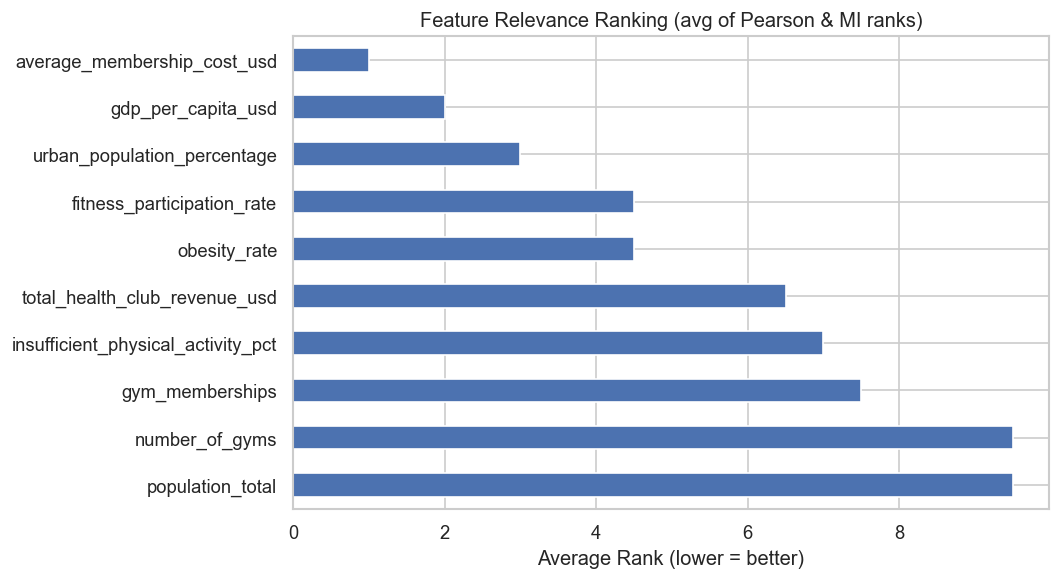

In [17]:
pearson_abs = corr_matrix[target].drop(target).abs()

mi_num = mi_series.drop("region_enc", errors="ignore").reindex(numeric_features)

ranking = pd.DataFrame({
    "pearson_abs": pearson_abs,
    "mutual_info": mi_num,
})
ranking["pearson_rank"] = ranking["pearson_abs"].rank(ascending=False)
ranking["mi_rank"] = ranking["mutual_info"].rank(ascending=False)
ranking["avg_rank"] = (ranking["pearson_rank"] + ranking["mi_rank"]) / 2
ranking = ranking.sort_values("avg_rank")

print("Combined Feature Ranking (lower avg_rank = more relevant):\n")
print(ranking.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
ranking["avg_rank"].plot(kind="barh", ax=ax, color="#4c72b0", edgecolor="white")
ax.invert_yaxis()
ax.set_title("Feature Relevance Ranking (avg of Pearson & MI ranks)")
ax.set_xlabel("Average Rank (lower = better)")
plt.tight_layout()
plt.show()


---
## EDA Conclusions

### Key Findings

1. **Target distribution** – `gym_penetration_rate` is right-skewed (most countries cluster below 0.10). Log-transforming the target before training may help the model.

2. **Regional patterns** – North America, Europe, and Oceania show significantly higher penetration rates than Africa and South Asia. `region` is a strong categorical signal.

3. **Temporal trend** – Penetration rates grow steadily over 2000–2026 globally; `year` carries temporal signal worth including.

4. **Strongest linear correlates with target**:
   - `gdp_per_capita_usd` (strong positive)
   - `average_membership_cost_usd` (positive)
   - `urban_population_percentage` (positive)
   - `fitness_participation_rate` (positive)
   - `insufficient_physical_activity_pct` (negative)

5. **Mutual information** confirms the above and additionally highlights `obesity_rate` as a non-linearly relevant feature.

6. **Multicollinearity** – `gym_memberships`, `number_of_gyms`, and `total_health_club_revenue_usd` are highly inter-correlated. Including all three adds noise without new information; prefer one (e.g., `gym_memberships`) or derive a density feature.

### Recommended Input Features for the Neural Network

| Feature | Type | Justification |
|---------|------|---------------|
| `gdp_per_capita_usd` | numeric | Strongest linear + MI signal |
| `urban_population_percentage` | numeric | Strong positive correlation |
| `fitness_participation_rate` | numeric | High MI & Pearson |
| `obesity_rate` | numeric | Non-linear signal (MI) |
| `average_membership_cost_usd` | numeric | Affects affordability |
| `insufficient_physical_activity_pct` | numeric | Health behaviour proxy |
| `year` | numeric | Temporal trend |
| `region` | categorical (encoded) | Large between-group variance |

Drop or avoid: `gym_memberships`, `number_of_gyms`, `total_health_club_revenue_usd`, `population_total` (leakage risk / collinear with target-derived features).

### Preprocessing Notes
- Log-transform or min-max scale heavy-tailed numeric features before feeding the network.
- One-hot encode `region` (8 categories).
- Consider log1p on target during training and exp on output for interpretability.
